<a href="https://colab.research.google.com/github/mchoirulbahriadzimi/morfologi/blob/main/MorfologiCitra.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
from google.colab import files  # Jika kamu pakai Google Colab
uploaded = files.upload()

# Ambil nama file yang di-upload
for file_name in uploaded.keys():
    image_path = file_name

Saving Prasasti.jpg to Prasasti (5).jpg


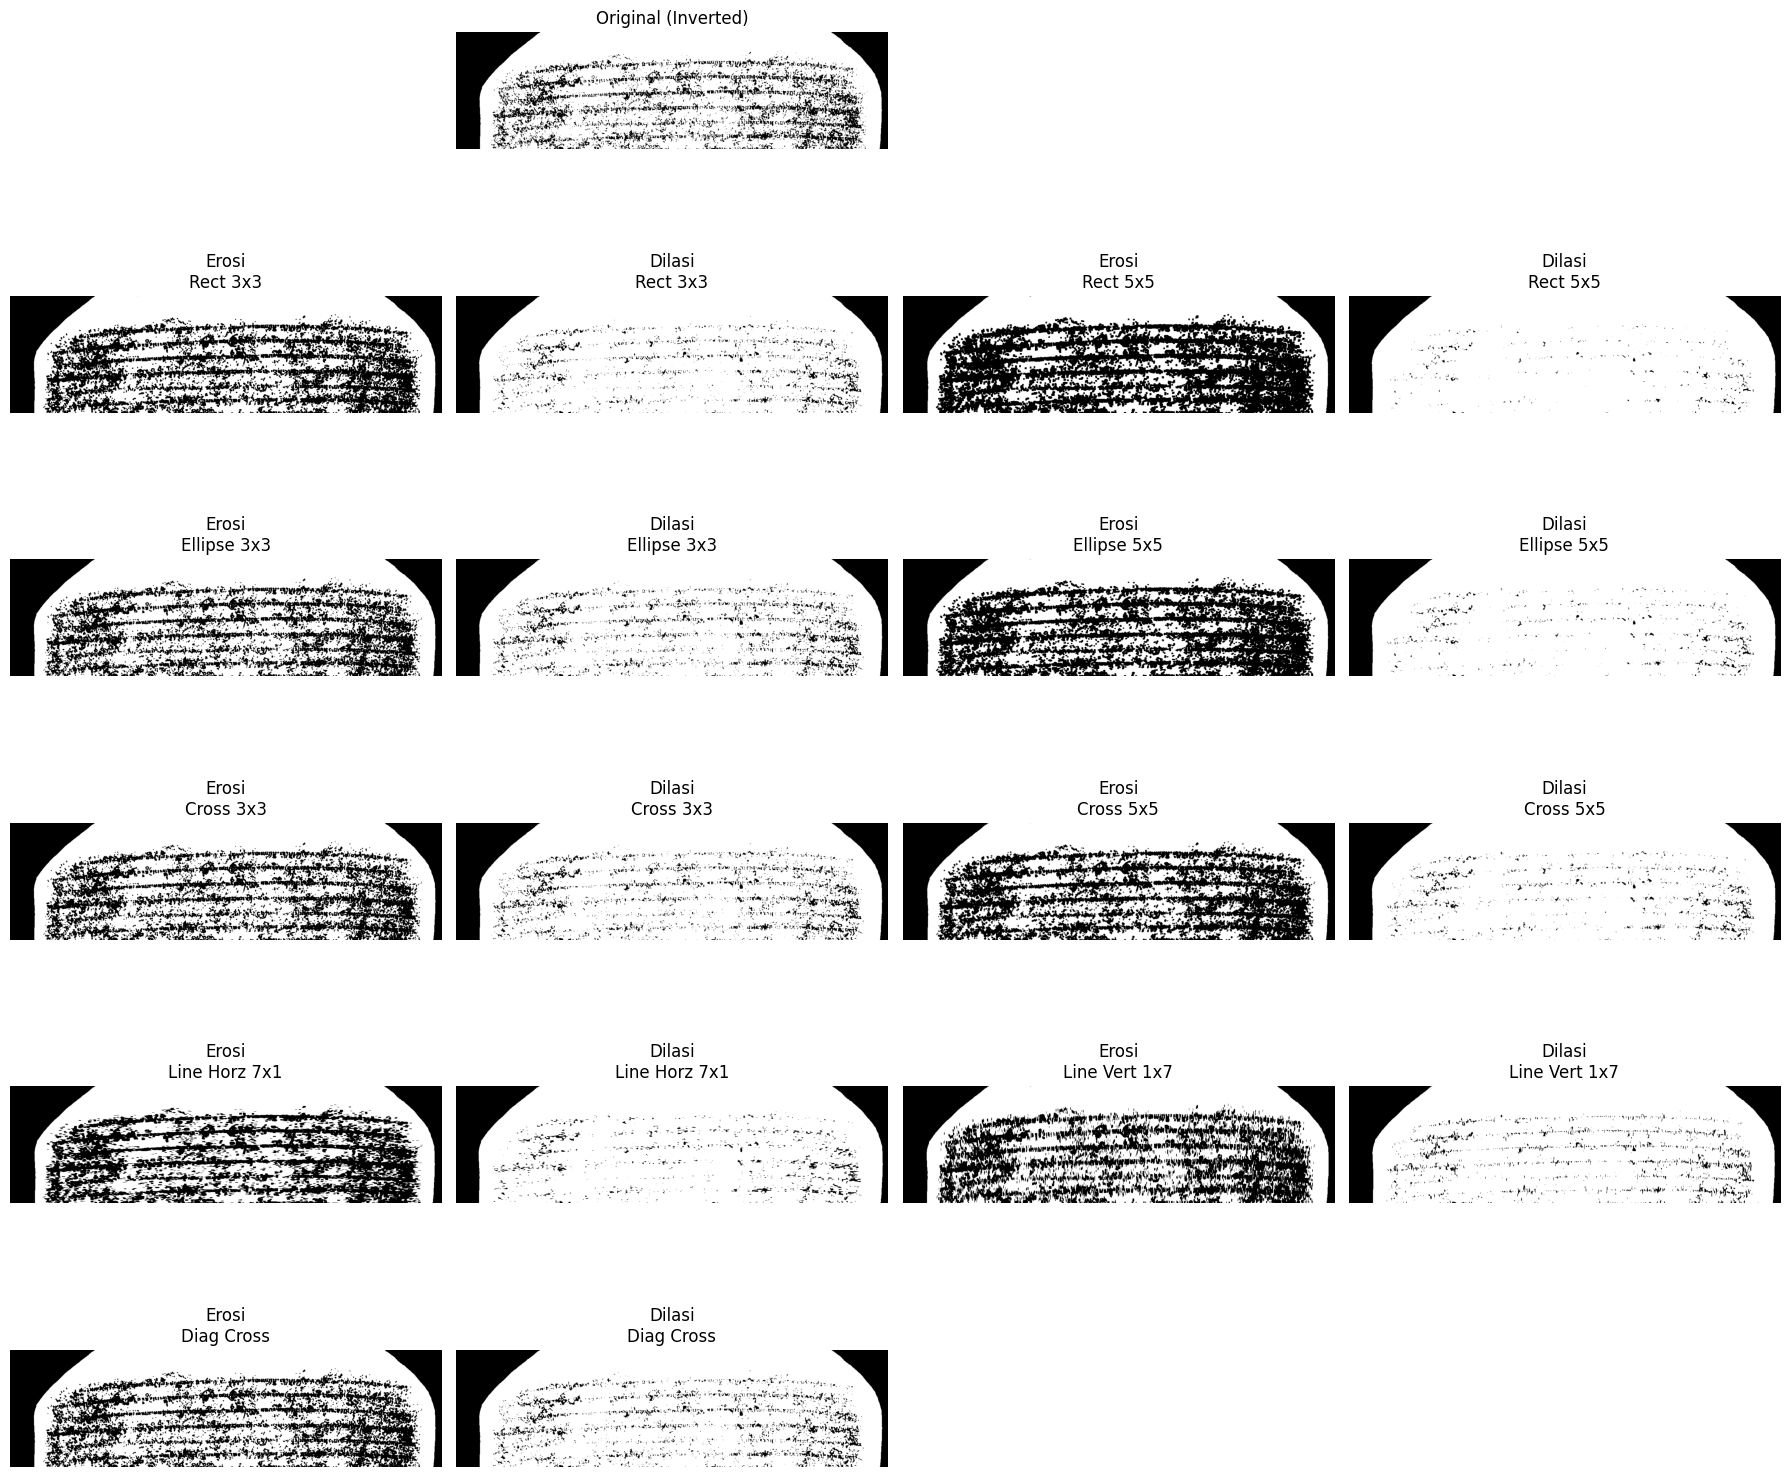

In [34]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Path ke gambar
image_path = "Prasasti.jpg"  # Ganti path jika diperlukan

# 1. Membaca gambar dalam mode grayscale
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
if img is None:
    raise FileNotFoundError("Gambar tidak ditemukan. Pastikan path sudah benar.")

# 2. Konversi ke citra biner dengan threshold, dan invert warnanya
_, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY_INV)

# 3. Definisikan 9 structuring elements (strels)
strels = {
    'Rect 3x3': cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3)),
    'Rect 5x5': cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5)),
    'Ellipse 3x3': cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3)),
    'Ellipse 5x5': cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5)),
    'Cross 3x3': cv2.getStructuringElement(cv2.MORPH_CROSS, (3, 3)),
    'Cross 5x5': cv2.getStructuringElement(cv2.MORPH_CROSS, (5, 5)),
    'Line Horz 7x1': cv2.getStructuringElement(cv2.MORPH_RECT, (7, 1)),
    'Line Vert 1x7': cv2.getStructuringElement(cv2.MORPH_RECT, (1, 7)),
    'Diag Cross': np.array([[0, 1, 0],
                            [1, 1, 1],
                            [0, 1, 0]], dtype=np.uint8)
}

# 4. Buat layout figure untuk menampilkan hasil
plt.figure(figsize=(18, 16))

# Gambar asli (inverted)
plt.subplot(6, 4, 2)
plt.imshow(binary, cmap='gray')
plt.title("Original (Inverted)")
plt.axis('off')

# 5. Iterasi setiap strel untuk proses erosi dan dilasi
index = 5
for name, strel in strels.items():
    # Erosi
    eroded = cv2.erode(binary, strel, iterations=1)
    plt.subplot(6, 4, index)
    plt.imshow(eroded, cmap='gray')
    plt.title(f"Erosi\n{name}")
    plt.axis('off')
    index += 1

    # Dilasi
    dilated = cv2.dilate(binary, strel, iterations=1)
    plt.subplot(6, 4, index)
    plt.imshow(dilated, cmap='gray')
    plt.title(f"Dilasi\n{name}")
    plt.axis('off')
    index += 1

plt.tight_layout()
plt.show()

Saving prasasti3.png to prasasti3 (5).png


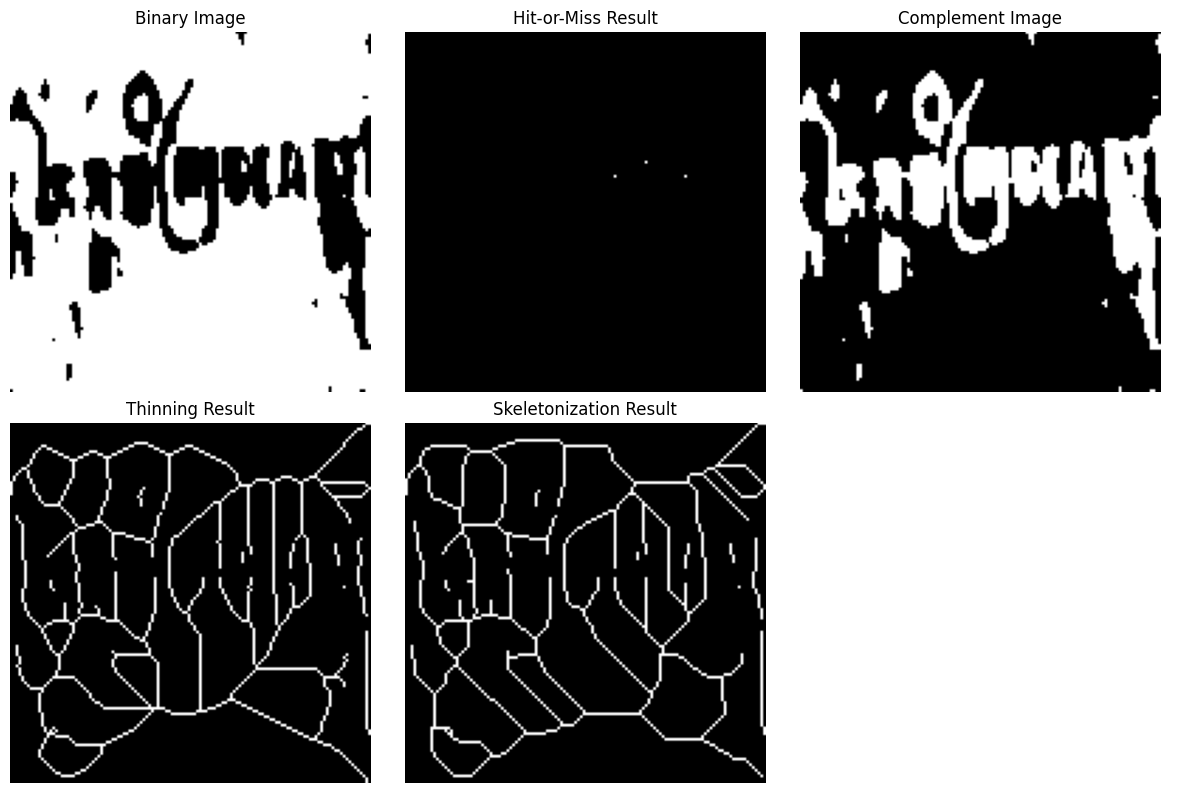

In [52]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import erosion, skeletonize, thin
from skimage.util import invert
from skimage import io, color
from skimage.filters import threshold_otsu
from skimage.transform import resize
from skimage.morphology import square
from google.colab import files  # Untuk Google Colab

# Fungsi Hit-or-Miss
def hit_or_miss(image, se_foreground, se_background):
    image_complement = invert(image)
    eroded_foreground = erosion(image, se_foreground)
    eroded_background = erosion(image_complement, se_background)
    hitmiss_result = eroded_foreground & eroded_background
    return hitmiss_result

# Fungsi Thinning
def thinning(image):
    return thin(image)

# Fungsi Skeletonization
def skeletonization(image):
    return skeletonize(image)

# Upload file
uploaded = files.upload()

# Ambil nama file pertama yang diupload
filename = next(iter(uploaded))

# Baca gambar
img = io.imread(filename)

# Konversi ke grayscale jika RGB/RGBA
if img.ndim == 3:
    if img.shape[2] == 4:  # Jika gambar RGBA
        img = img[:, :, :3]  # Buang channel alpha
    gray = color.rgb2gray(img)
else:
    gray = img

# Binarisasi dengan Otsu
thresh = threshold_otsu(gray)
binary = gray < thresh

# Resize opsional biar lebih kecil dan jelas
binary = resize(binary, (128, 128), anti_aliasing=False)

# Structuring Elements
se_foreground = np.array([
    [0, 1, 0],
    [0, 1, 0],
    [0, 0, 0]
], dtype=bool)

se_background = np.array([
    [1, 0, 1],
    [1, 0, 1],
    [1, 1, 1]
], dtype=bool)

# Proses Hit-or-Miss
hitmiss_result = hit_or_miss(binary, se_foreground, se_background)

# Proses Thinning
thinning_result = thinning(binary)

# Proses Skeletonization
skeleton_result = skeletonization(binary)

# Visualisasi
fig, axs = plt.subplots(2, 3, figsize=(12, 8))
axs[0, 0].imshow(binary, cmap='gray')
axs[0, 0].set_title("Binary Image")

axs[0, 1].imshow(hitmiss_result, cmap='gray')
axs[0, 1].set_title("Hit-or-Miss Result")

axs[0, 2].imshow(invert(binary), cmap='gray')
axs[0, 2].set_title("Complement Image")

axs[1, 0].imshow(thinning_result, cmap='gray')
axs[1, 0].set_title("Thinning Result")

axs[1, 1].imshow(skeleton_result, cmap='gray')
axs[1, 1].set_title("Skeletonization Result")

for ax in axs.flat:
    ax.axis('off')

plt.tight_layout()
plt.show()